# 04 — Business Impact and Threshold Analysis

## Objetivo
Este notebook traduce el modelo final a una lógica de decisión operativa y de negocio. El propósito es:

1. analizar el efecto de distintos thresholds en el rendimiento de la regresión logística,
2. seleccionar un umbral operativo razonable,
3. evaluar la capacidad de priorización del modelo mediante `Recall@Top10%`,
4. y traducir el rendimiento del modelo a escenarios de impacto económico.

## Preguntas que responde
- ¿Qué threshold conviene usar en producción?
- ¿Cuánto churn capturamos en el top 10% de mayor riesgo?
- ¿Qué mejora aporta el modelo frente a una selección aleatoria?
- ¿Cómo se traduce esto en valor retenido esperado?

In [8]:
from pathlib import Path
import sys
import warnings

# === PROJECT ROOT ===
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

# === CONFIG ===
warnings.filterwarnings("ignore")

PROJECT_ROOT = C:\repos\tfm-proyecto1-churn


In [9]:
import pandas as pd
import numpy as np

from src.models.threshold_analysis import evaluate_thresholds
from src.business.business_impact import build_business_impact_table

In [10]:
from IPython.display import Image, display
from pathlib import Path

In [11]:
threshold_df = evaluate_thresholds()
threshold_df

,threshold,accuracy,precision,recall,f1
0,0.30,0.7495,0.5193,0.7540,0.6150
1,0.35,0.7644,0.5432,0.7059,0.6140
2,0.40,0.7771,0.5682,0.6684,0.6143
3,0.45,0.7892,0.6005,0.6150,0.6077
4,0.50,0.8055,0.6572,0.5588,0.6040
5,0.55,0.7991,0.6784,0.4626,0.5501
6,0.60,0.7991,0.7177,0.4011,0.5146


## Interpretación del trade-off entre precision y recall

El análisis de thresholds muestra el comportamiento esperado: al reducir el umbral, aumenta la capacidad de detección de churners (`recall`), pero disminuye la `precision`. A la inversa, al aumentar el threshold, el modelo se vuelve más conservador, mejora la precisión, pero deja escapar más clientes en riesgo.

En un problema de churn, donde perder un cliente suele ser más costoso que contactar a uno que finalmente no abandona, resulta razonable priorizar umbrales que mantengan un recall relativamente alto.

In [12]:
threshold_df[threshold_df["threshold"].isin([0.40, 0.50])]

,threshold,accuracy,precision,recall,f1
2,0.4,0.7771,0.5682,0.6684,0.6143
4,0.5,0.8055,0.6572,0.5588,0.6040


## Threshold recomendado

Se propone un **threshold operativo de 0.40**, ya que ofrece un equilibrio razonable entre:

- `precision = 0.5682`
- `recall = 0.6684`
- `f1 = 0.6143`

Frente al umbral estándar de 0.50, el threshold 0.40 permite capturar una proporción claramente mayor de churners, a costa de aceptar un incremento moderado en falsas alarmas. Esta decisión es coherente con un caso de uso de retención.

## Priorization metric: Recall@Top10%

La métrica más alineada con el caso de uso es `Recall@Top10%`, ya que representa un escenario realista en el que la empresa solo puede actuar sobre el 10% de clientes con mayor riesgo estimado.

Esta métrica responde a la pregunta:

> ¿Qué porcentaje del churn total consigo capturar si actúo solo sobre el 10% de clientes con mayor probabilidad estimada?

In [13]:
impact_df = build_business_impact_table(k=0.10, random_state=42)
impact_df

,Escenario,TopK,Clientes_contactados,Churners_totales_test,Recall@TopK_modelo,Recall@TopK_azar,Churners_capturados_modelo,Churners_capturados_azar,Valor_por_cliente_retenido_V,Coste_por_contacto_C,Tasa_exito_campaña_r,Impacto_neto_modelo,Impacto_neto_azar,Impacto_incremental_modelo
0,Conservador,0.1,140,374,0.2781,0.1096,104,41,300,10,0.20,4840.0,1060.0,3780.0
1,Base,0.1,140,374,0.2781,0.1096,104,41,500,15,0.25,10900.0,3025.0,7875.0
2,Agresivo,0.1,140,374,0.2781,0.1096,104,41,800,20,0.30,22160.0,7040.0,15120.0


## Interpretación del impacto de negocio

La regresión logística alcanza un `Recall@Top10% = 0.2781`, frente al `0.1096` de una selección aleatoria. Esto implica que el modelo captura aproximadamente **2.5–2.7 veces más churn real** que una campaña sin inteligencia predictiva, manteniendo constante la misma capacidad operativa.

En el conjunto de test, esto significa que al actuar sobre el top 10% de clientes priorizados:

- el modelo identifica aproximadamente **104 churners reales**,
- mientras que una selección aleatoria capturaría solo unos **41**.

La diferencia es, por tanto, de aproximadamente **63 churners adicionales identificados** gracias al modelo.

C:\repos\tfm-proyecto1-churn\reports\figures\business\business_impact_incremental.png
True


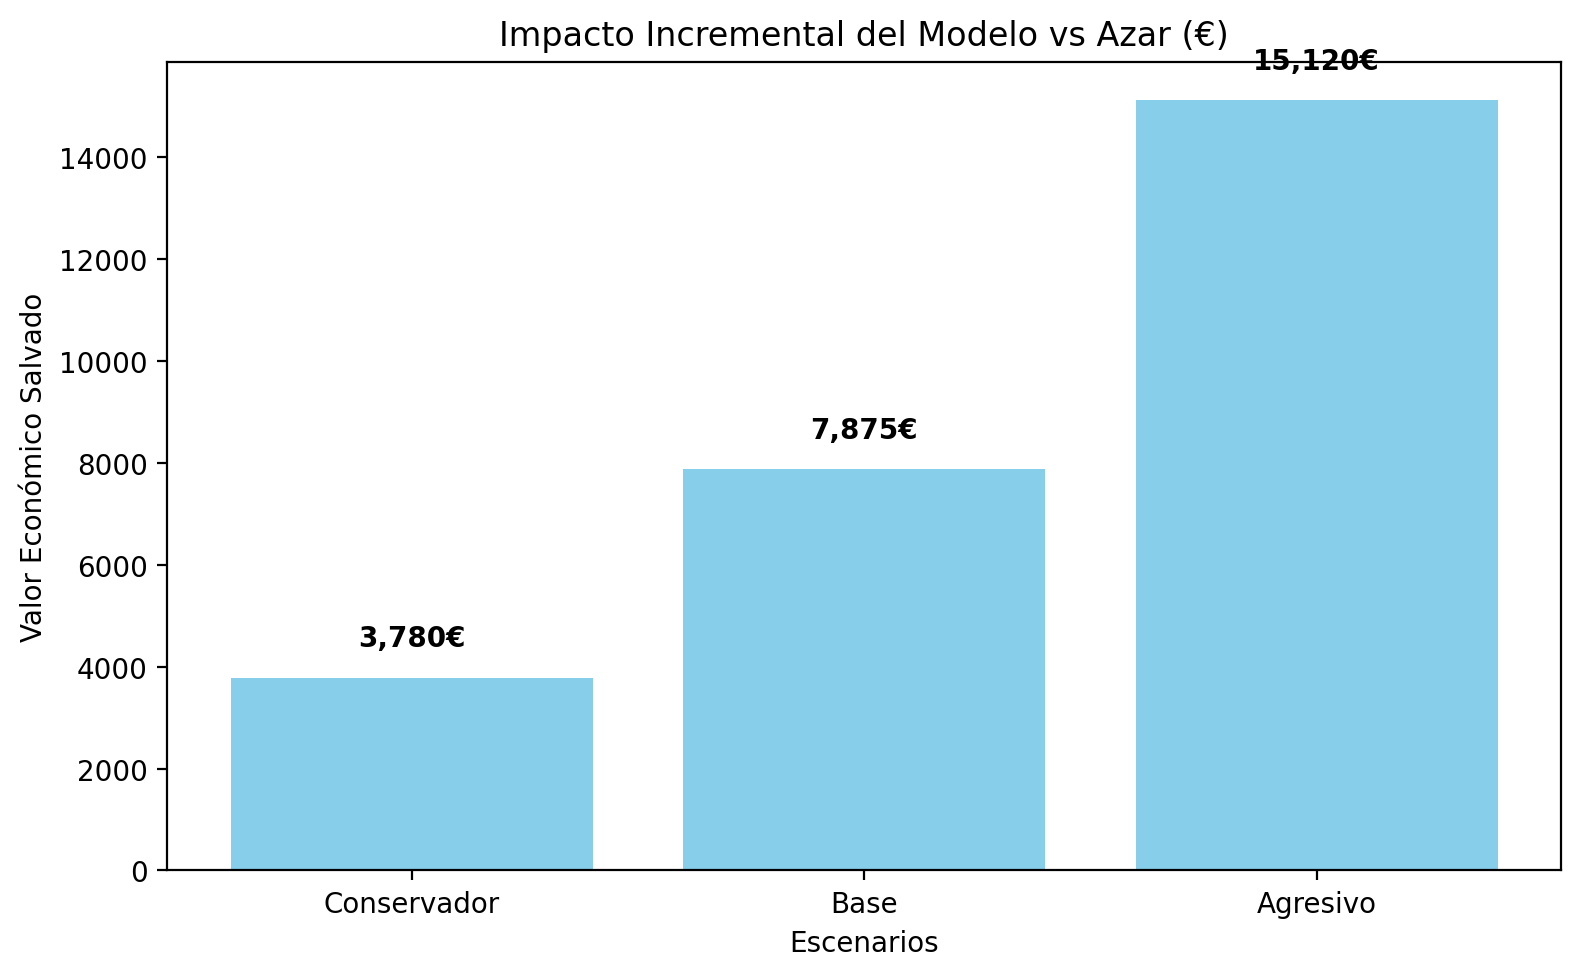

In [14]:
impact_plot_path = PROJECT_ROOT / "reports" / "figures" / "business" / "business_impact_incremental.png"
print(impact_plot_path)
print(impact_plot_path.exists())

display(Image(filename=str(impact_plot_path)))

## Traducción económica

El impacto neto esperado puede expresarse como:

\[
Impacto\_neto = TP_{top10}\cdot r \cdot V - N_{top10}\cdot C
\]

donde:

- \(TP_{top10}\): churners capturados en el top 10%,
- \(r\): tasa de éxito de la campaña,
- \(V\): valor esperado por cliente retenido,
- \(N_{top10}\): número de clientes contactados,
- \(C\): coste por intervención.

Esta formulación permite traducir el valor predictivo del modelo a escenarios económicos conservador, base y agresivo.

## Lectura ejecutiva de escenarios

En los tres escenarios analizados, el modelo produce un impacto neto superior al de una selección aleatoria. La mejora no proviene de contactar a más clientes, sino de identificar mejor a los churners reales dentro de la misma capacidad operativa.

Por tanto, el modelo no solo tiene valor técnico, sino que puede traducirse en una mejora operativa y económica defendible para campañas de retención.

## Conclusión

La fase de umbral e impacto de negocio confirma que la utilidad del modelo no debe medirse únicamente con métricas técnicas globales, sino en función de su capacidad para soportar decisiones operativas reales.

El proyecto concluye que:

- la **regresión logística** es el modelo principal seleccionado,
- el **threshold operativo recomendado** es **0.40**,
- y la priorización sobre el **top 10% de clientes con mayor riesgo** genera un valor claramente superior al de una estrategia aleatoria.

Con ello, el proyecto queda cerrado como una solución *end-to-end* que conecta problema de negocio, modelado, explicabilidad, decisión operativa e impacto económico.